In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter

sns.set_theme(style="whitegrid")

# 1. Chargement du dataset
# index_col=0 permet d'absorber la première colonne vide (l'index) de ton fichier
data = pd.read_csv("../german_credit_data.csv", index_col=0)

# Affichage des colonnes pour identifier formellement la variable de défaut
print("Colonnes disponibles :", data.columns.tolist())
display(data.head(3))

Colonnes disponibles : ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education


Nombre de défauts simulés : 231 sur 1000 crédits


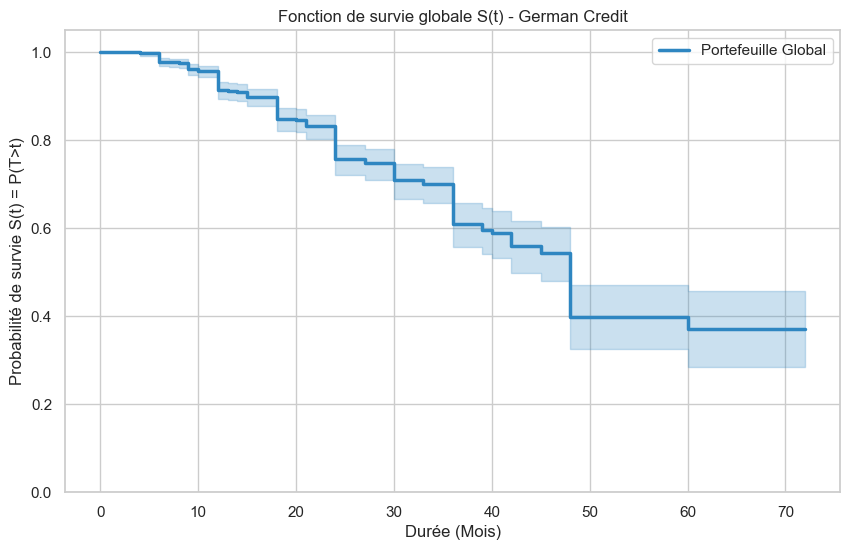

In [15]:
import numpy as np
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# 1. Création de la variable T (Temps)
data['time'] = data['Duration']

# 2. Gestion des valeurs manquantes pour l'épargne (on assume 'little' par défaut)
data['Saving accounts'] = data['Saving accounts'].fillna('little')

# 3. Calcul de la probabilité de défaut personnalisée par client
np.random.seed(42)
prob_defaut = np.full(len(data), 0.25) # Risque de base à 25%

# Pénalité : +15% de risque si le crédit est au-dessus de la médiane
median_credit = data['Credit amount'].median()
prob_defaut += np.where(data['Credit amount'] > median_credit, 0.15, 0.0)

# Bonus : -15% de risque si le client a une bonne épargne
prob_defaut -= np.where(data['Saving accounts'].isin(['quite rich', 'rich']), 0.15, 0.0)

# Bonus : -10% de risque si le client a un emploi qualifié (Job = 2 ou 3)
prob_defaut -= np.where(data['Job'] >= 2, 0.10, 0.0)

# Sécurité : on borne les probabilités entre 5% et 95%
prob_defaut = np.clip(prob_defaut, 0.05, 0.95)

# 4. Génération de la colonne événement
data['event'] = np.random.binomial(1, prob_defaut)
print(f"Nombre de défauts simulés : {data['event'].sum()} sur {len(data)} crédits")

# 5. Modélisation Kaplan-Meier Globale
kmf = KaplanMeierFitter()
kmf.fit(durations=data['time'], event_observed=data['event'], label='Portefeuille Global')

plt.figure(figsize=(10, 6))
kmf.plot_survival_function(linewidth=2.5, color='#2E86C1')
plt.title('Fonction de survie globale S(t) - German Credit')
plt.xlabel('Durée (Mois)')
plt.ylabel('Probabilité de survie S(t) = P(T>t)')
plt.ylim(0, 1.05)
plt.show()

In [16]:
data.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,time,event
0,67,male,2,own,little,little,1169,6,radio/TV,6,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,48,1
2,49,male,1,own,little,NaN,2096,12,education,12,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,42,0
4,53,male,2,free,little,little,4870,24,car,24,0
